## DATA

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("DataPod_Hourly.csv")
df

,DEVICE,DATE,DISSOLVED OXYGEN,ORP,PH,CONDUCTIVITY,TEMPERATURE
0,Lifeguard Dock DataPod™,04:21 09/05/2025,0.000000,-204.399994,1.941,24440.000000,77.876599
1,Lifeguard Dock DataPod™,01:29 08/07/2025,4.060000,-99.599998,5.873,46210.000000,76.321399
2,Lifeguard Dock DataPod™,00:59 08/07/2025,3.920000,-107.400002,6.225,46750.000000,76.382599
3,Lifeguard Dock DataPod™,00:30 08/07/2025,4.110000,-101.900002,6.227,46910.000000,76.353801
4,Lifeguard Dock DataPod™,00:00 08/07/2025,4.190000,-99.500000,6.342,46980.000000,76.332199
...,...,...,...,...,...,...,...
16856,Lifeguard Dock DataPod™,23:51 05/13/2024,2.360000,238.399994,8.896,0.000000,72.316401
16857,Lifeguard Dock DataPod™,18:18 05/10/2024,7.250000,132.500000,7.351,116.099998,73.918400
16858,Lifeguard Dock DataPod™,14:28 05/10/2024,1.000000,74.500000,8.204,0.000000,70.464199
16859,Lifeguard Dock DataPod™,20:43 05/09/2024,1.400000,70.500000,8.113,0.000000,76.859602


In [3]:
df = df[["DATE", "DISSOLVED OXYGEN", "ORP", "PH", "CONDUCTIVITY","TEMPERATURE"]].copy()

In [4]:
df["DATE"] = pd.to_datetime(df["DATE"])
df.set_index("DATE", inplace=True)
df = df.sort_index(ascending=True)

In [5]:
df.columns = ["DO", "ORP", "PH", "COND", "TEMP"]

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_vals = scaler.fit_transform(df)

n_past = 72   
n_future = 24  
n_features = 5 

def create_sequences(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        y.append(data[i:i + n_future, :])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_vals, n_past, n_future)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape

model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(n_past, n_features)),
    Dropout(0.2),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    
    Dense(n_future * n_features),
    Reshape((n_future, n_features)) 
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=30, batch_size=32, 
                    validation_data=(X_test, y_test), verbose=1)

C:\Users\ginaj\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 74s 162ms/step - loss: 0.0636 - val_loss: 0.0021
Epoch 2/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 69s 163ms/step - loss: 0.0081 - val_loss: 0.0016
Epoch 3/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 67s 160ms/step - loss: 0.0060 - val_loss: 0.0015
Epoch 4/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 68s 161ms/step - loss: 0.0050 - val_loss: 0.0013
Epoch 5/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 68s 163ms/step - loss: 0.0044 - val_loss: 0.0011
Epoch 6/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 61s 146ms/step - loss: 0.0042 - val_loss: 0.0011
Epoch 7/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 54s 129ms/step - loss: 0.0036 - val_loss: 9.2330e-04
Epoch 8/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 56s 134ms/step - loss: 0.0034 - val_loss: 9.6099e-04
Epoch 9/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 61s 146ms/step - loss: 0.0031 - val_loss: 0.0011
Epoch 10/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 57s 136ms/step - loss: 0.0029 - val_loss: 9.7961e-04
Epoch 11/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 68s 162ms/step - loss: 0.0028 - val_loss: 0.0011
Epoch 1

In [8]:
latest_window = scaled_vals[-n_past:] 
latest_window = latest_window.reshape(1, n_past, n_features)

prediction_scaled = model.predict(latest_window)

forecast = scaler.inverse_transform(prediction_scaled[0])

forecast_df = pd.DataFrame(forecast, columns=df.columns)
forecast_df.index = pd.date_range(start=df.index[-1] + pd.Timedelta(hours=1), 
                                  periods=24, freq='H')

print("--- 24 Hour Water Quality Forecast ---")
print(forecast_df.head())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
--- 24 Hour Water Quality Forecast ---
                           DO        ORP        PH          COND       TEMP
2025-09-05 05:21:00  2.413461 -30.036409  3.564281  50582.167969  77.262589
2025-09-05 06:21:00  2.408238 -30.650810  3.411238  49054.414062  79.872879
2025-09-05 07:21:00  2.291712 -24.652990  3.315942  48575.648438  79.370979
2025-09-05 08:21:00  2.462757 -27.285341  3.160418  52727.925781  69.413536
2025-09-05 09:21:00  2.199865 -21.717329  3.061657  50271.804688  77.283272


C:\Users\ginaj\AppData\Local\Temp\ipykernel_19812\1523131549.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_df.index = pd.date_range(start=df.index[-1] + pd.Timedelta(hours=1),


## TESTING

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_scaled = model.predict(X_test)


y_test_reshaped = y_test.reshape(-1, n_features)
y_pred_reshaped = y_pred_scaled.reshape(-1, n_features)

y_test_inv = scaler.inverse_transform(y_test_reshaped).reshape(y_test.shape)
y_pred_inv = scaler.inverse_transform(y_pred_reshaped).reshape(y_pred_scaled.shape)

print("Perofrmance Metrics")

for i, col_name in enumerate(df.columns):
    actual = y_test_inv[:, :, i].flatten()
    predicted = y_pred_inv[:, :, i].flatten()
    
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    
    print(f"{col_name:15} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")


105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step
Perofrmance Metrics
DO              | MAE: 0.8288 | RMSE: 0.9171
ORP             | MAE: 45.3884 | RMSE: 60.4967
PH              | MAE: 0.7497 | RMSE: 1.5689
COND            | MAE: 5851.1986 | RMSE: 6985.4424
TEMP            | MAE: 8.3257 | RMSE: 9.7507


In [29]:
def plot_indicator(variable_name, sequence_idx):
    column_list = list(df.columns)

    var_idx = column_list.index(variable_name)
    
    actual_values = y_test_inv[sequence_idx, :, var_idx]
    predicted_values = y_pred_inv[sequence_idx, :, var_idx]
    
    plt.figure(figsize=(10, 5))
    plt.style.use('dark_background')
    plt.plot(actual_values, label='Actual', marker='o', color='gray', alpha=0.7)
    plt.plot(predicted_values, label='Forecasted', marker='o', linestyle='--', color='cornflowerblue')
    
    max_val = max(np.max(actual_values), np.max(predicted_values))
    plt.ylim(0, max_val * 1.15)
    
    plt.title(f"24-Hour Forecast: {variable_name} (Test Sample {sequence_idx})")
    plt.xlabel("Hours")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

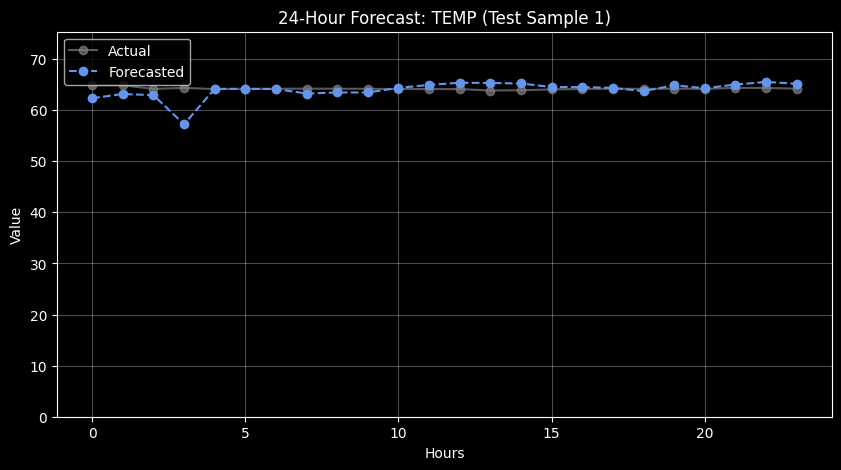

In [33]:
plot_indicator("TEMP", 1)